In [2]:
pip install -q git+https://github.com/amazon-science/chronos-forecasting.git

Note: you may need to restart the kernel to use updated packages.


In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 

from chronos import ChronosPipeline 
from datetime import datetime
import torch

from statsmodels.graphics.tsaplots import month_plot, quarter_plot, \
                                          plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose, seasonal_mean

from sklearn.metrics import mean_absolute_error, mean_squared_error, \
                            root_mean_squared_error, mean_absolute_percentage_error
from sklearn.model_selection import ParameterGrid

In [3]:
import tsdb

In [5]:
df = pd.DataFrame(tsdb.load('beijing_multisite_air_quality')['X'])
df.head()

2025-03-08 15:45:45 [INFO]: You're using dataset beijing_multisite_air_quality, please cite it properly in your work. You can find its reference information at the below link: 
https://github.com/WenjieDu/TSDB/tree/main/dataset_profiles/beijing_multisite_air_quality
2025-03-08 15:45:45 [INFO]: Dataset beijing_multisite_air_quality has already been downloaded. Processing directly...
2025-03-08 15:45:45 [INFO]: Dataset beijing_multisite_air_quality has already been cached. Loading from cache directly...
2025-03-08 15:45:45 [INFO]: Loaded successfully!


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,3.0,6.0,3.0,8.0,300.0,44.0,-0.9,1025.8,-20.5,0.0,NW,9.3,Shunyi
1,2,2013,3,1,1,12.0,12.0,3.0,7.0,300.0,47.0,-1.1,1026.1,-21.3,0.0,NW,9.4,Shunyi
2,3,2013,3,1,2,14.0,14.0,NaN,7.0,200.0,22.0,-1.7,1026.2,-23.0,0.0,NW,8.6,Shunyi
3,4,2013,3,1,3,12.0,12.0,3.0,5.0,NaN,NaN,-2.1,1027.3,-23.3,0.0,NW,6.6,Shunyi
4,5,2013,3,1,4,12.0,12.0,3.0,NaN,200.0,11.0,-2.4,1027.7,-22.9,0.0,NW,4.5,Shunyi


In [6]:
df.rename(columns = {'TEMP': 'y'}, inplace = True)

<Axes: xlabel='ds'>

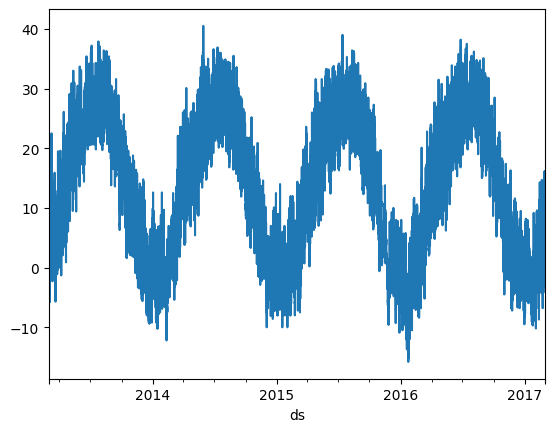

In [ ]:
def clean_datetime(df):
    dttime = str(df['year']) + '-' + str(df['month']) + '-' + str(df['day']) + \
        ' ' + str(df['hour']) + ':00:00'
    
    return datetime.strptime(dttime, '%Y-%m-%d %H:%M:%S')

df['ds'] = df.apply(clean_datetime, axis = 1)

df.set_index('ds', inplace=True)
df = df.query('station == "Wanliu"')['y']
df = df.asfreq('h')


df.plot()

/tmp/ipykernel_1532/3737615178.py:7: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  quarter_plot(df.resample('Q').mean(),


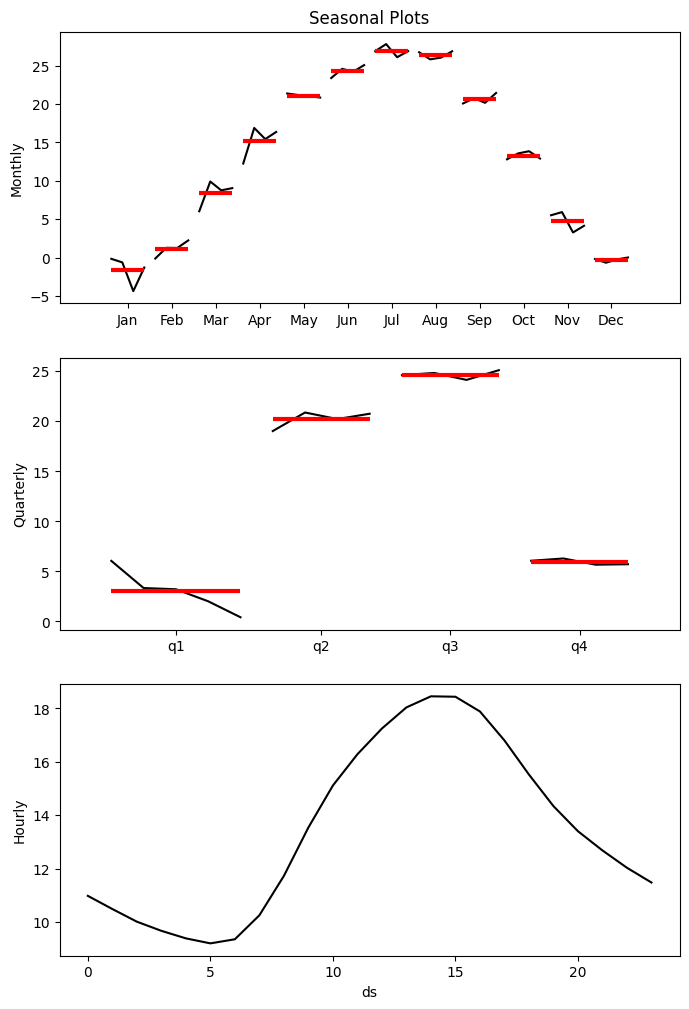

In [45]:
fig, ax = plt.subplots(3, 1, figsize = (8, 12))

month_plot(df.resample('ME').mean(),
           ylabel = 'Monthly',
           ax=ax[0])

quarter_plot(df.resample('Q').mean(),
             ylabel='Quarterly',
             ax = ax[1])

df.groupby(df.index.hour).mean().plot(ax=ax[2],
                                      color='black',
                                      ylabel='Hourly')

ax[0].set_title('Seasonal Plots')

plt.show()

In [46]:
pipeline = ChronosPipeline.from_pretrained(
    'amazon/chronos-t5-base'
)